Phase 1


In [1]:
!pip install yfinance


In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
from datetime import datetime


In [3]:
ticker = yf.Ticker("SPY")


In [10]:
S0 = ticker.history(period="1d")["Close"].iloc[-1]
S0


np.float64(681.75)

In [4]:
expirations = ticker.options
expirations[:5]


('2026-02-17', '2026-02-18', '2026-02-19', '2026-02-20', '2026-02-23')

In [6]:
selected_expirations = expirations[:4]
selected_expirations


('2026-02-17', '2026-02-18', '2026-02-19', '2026-02-20')

In [7]:
option_data = []

for expiry in selected_expirations:
    chain = ticker.option_chain(expiry)
    calls = chain.calls.copy()

    calls["expiration"] = expiry
    option_data.append(calls)

options_df = pd.concat(option_data)
options_df.head()


,contractSymbol,lastTradeDate,strike,lastPrice,bid,ask,change,percentChange,volume,openInterest,impliedVolatility,inTheMoney,contractSize,currency,expiration
0,SPY260217C00500000,2026-02-10 15:01:14+00:00,500.0,196.00,180.46,183.18,0.000000,0.000000,NaN,0,1.093755,True,REGULAR,USD,2026-02-17
1,SPY260217C00550000,2026-02-10 15:01:14+00:00,550.0,146.07,130.47,133.19,0.000000,0.000000,4.0,1,0.794924,True,REGULAR,USD,2026-02-17
2,SPY260217C00595000,2026-02-13 15:40:33+00:00,595.0,87.70,85.49,88.13,-10.570000,-10.756081,1.0,11,0.511724,True,REGULAR,USD,2026-02-17
3,SPY260217C00635000,2026-02-13 18:47:39+00:00,635.0,50.49,45.53,48.23,4.830002,10.578191,288.0,2,0.508306,True,REGULAR,USD,2026-02-17
4,SPY260217C00640000,2026-02-13 14:53:21+00:00,640.0,40.26,40.55,43.24,-1.520001,-3.638105,13.0,2,0.466680,True,REGULAR,USD,2026-02-17


In [8]:
today = datetime.today()

options_df["T"] = options_df["expiration"].apply(
    lambda x: (datetime.strptime(x, "%Y-%m-%d") - today).days / 365
)

options_df = options_df[options_df["T"] > 0]


In [11]:
options_df = options_df[
    (options_df["strike"] > 0.8 * S0) &
    (options_df["strike"] < 1.2 * S0)
]

options_df = options_df.dropna(subset=["lastPrice"])
options_df.head()


,contractSymbol,lastTradeDate,strike,lastPrice,bid,ask,change,percentChange,volume,openInterest,impliedVolatility,inTheMoney,contractSize,currency,expiration,T
1,SPY260217C00550000,2026-02-10 15:01:14+00:00,550.0,146.07,130.47,133.19,0.000000,0.000000,4.0,1,0.794924,True,REGULAR,USD,2026-02-17,0.005479
2,SPY260217C00595000,2026-02-13 15:40:33+00:00,595.0,87.70,85.49,88.13,-10.570000,-10.756081,1.0,11,0.511724,True,REGULAR,USD,2026-02-17,0.005479
3,SPY260217C00635000,2026-02-13 18:47:39+00:00,635.0,50.49,45.53,48.23,4.830002,10.578191,288.0,2,0.508306,True,REGULAR,USD,2026-02-17,0.005479
4,SPY260217C00640000,2026-02-13 14:53:21+00:00,640.0,40.26,40.55,43.24,-1.520001,-3.638105,13.0,2,0.466680,True,REGULAR,USD,2026-02-17,0.005479
5,SPY260217C00645000,2026-02-13 21:07:44+00:00,645.0,36.40,35.56,38.25,-3.099998,-7.848097,15.0,9,0.424444,True,REGULAR,USD,2026-02-17,0.005479


Phase 2


In [12]:
from scipy.stats import norm

def black_scholes_call(S, K, T, r, sigma):
    d1 = (np.log(S/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)

    call_price = S * norm.cdf(d1) - K * np.exp(-r*T) * norm.cdf(d2)
    return call_price

def vega(S, K, T, r, sigma):
    d1 = (np.log(S/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    return S * norm.pdf(d1) * np.sqrt(T)

#Black Scholes Equations

In [13]:
r = 0.04  # 4% annual risk-free rate (approx US)


In [14]:
test_sigma = 0.20

options_df["bs_price"] = options_df.apply(
    lambda row: black_scholes_call(
        S0,
        row["strike"],
        row["T"],
        r,
        test_sigma
    ),
    axis=1
)

options_df[["strike", "T", "lastPrice", "bs_price"]].head()


,strike,T,lastPrice,bs_price
1,550.0,0.005479,146.07,131.870535
2,595.0,0.005479,87.70,86.880397
3,635.0,0.005479,50.49,46.889164
4,640.0,0.005479,40.26,41.890278
5,645.0,0.005479,36.40,36.891554


In [15]:
test_sigma = 0.20

options_df["bs_price"] = options_df.apply(
    lambda row: black_scholes_call(
        S0,
        row["strike"],
        row["T"],
        r,
        test_sigma
    ),
    axis=1
)

options_df[["strike", "T", "lastPrice", "bs_price"]].head()


,strike,T,lastPrice,bs_price
1,550.0,0.005479,146.07,131.870535
2,595.0,0.005479,87.70,86.880397
3,635.0,0.005479,50.49,46.889164
4,640.0,0.005479,40.26,41.890278
5,645.0,0.005479,36.40,36.891554


Phase 3


In [16]:
def implied_volatility(S, K, T, r, market_price, tol=1e-5, max_iter=100):
    sigma = 0.2  # initial guess

    for i in range(max_iter):
        price = black_scholes_call(S, K, T, r, sigma)
        v = vega(S, K, T, r, sigma)

        price_diff = price - market_price

        if abs(price_diff) < tol:
            return sigma

        sigma = sigma - price_diff / v

    return np.nan


In [17]:
options_df["implied_vol"] = options_df.apply(
    lambda row: implied_volatility(
        S0,
        row["strike"],
        row["T"],
        r,
        row["lastPrice"]
    ),
    axis=1
)

options_df[["strike", "T", "implied_vol"]].head()


/tmp/ipython-input-2231192689.py:13: RuntimeWarning: divide by zero encountered in scalar divide
  sigma = sigma - price_diff / v
/tmp/ipython-input-3056119819.py:4: RuntimeWarning: invalid value encountered in scalar divide
  d1 = (np.log(S/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
/tmp/ipython-input-3056119819.py:11: RuntimeWarning: invalid value encountered in scalar divide
  d1 = (np.log(S/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
/tmp/ipython-input-3056119819.py:4: RuntimeWarning: overflow encountered in scalar power
  d1 = (np.log(S/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
/tmp/ipython-input-3056119819.py:11: RuntimeWarning: overflow encountered in scalar power
  d1 = (np.log(S/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))


,strike,T,implied_vol
1,550.0,0.005479,NaN
2,595.0,0.005479,NaN
3,635.0,0.005479,NaN
4,640.0,0.005479,NaN
5,645.0,0.005479,NaN


Phase 4


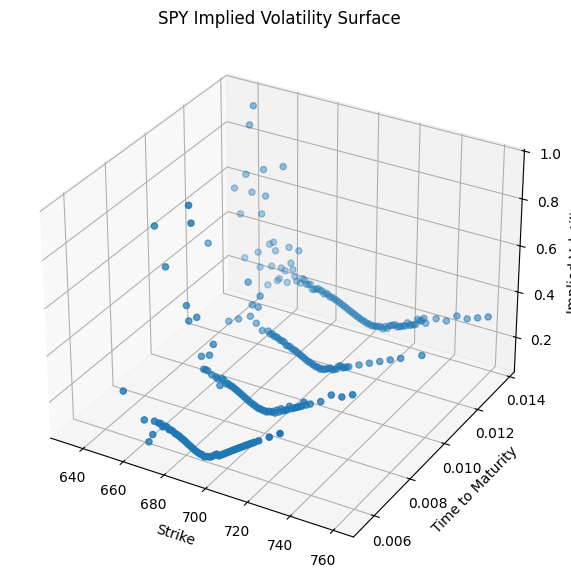

In [21]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    options_df["strike"],
    options_df["T"],
    options_df["implied_vol"]
)

ax.set_xlabel("Strike")
ax.set_ylabel("Time to Maturity")
ax.set_zlabel("Implied Volatility")

plt.title("SPY Implied Volatility Surface")
plt.show()


Phase 5

In [22]:
def monte_carlo_call(S, K, T, r, sigma, n_sim=10000):
    Z = np.random.normal(0, 1, n_sim)

    ST = S * np.exp((r - 0.5*sigma**2)*T + sigma*np.sqrt(T)*Z)

    payoff = np.maximum(ST - K, 0)

    price = np.exp(-r*T) * np.mean(payoff)

    return price


In [23]:
atm_option = options_df.iloc[
    (options_df["strike"] - S0).abs().argsort()[:1]
].iloc[0]

K_atm = atm_option["strike"]
T_atm = atm_option["T"]
sigma_atm = atm_option["implied_vol"]

K_atm, T_atm, sigma_atm


(np.float64(682.0),
 np.float64(0.0136986301369863),
 np.float64(0.19661255761146101))

In [24]:
bs_price = black_scholes_call(S0, K_atm, T_atm, r, sigma_atm)

mc_price = monte_carlo_call(S0, K_atm, T_atm, r, sigma_atm, n_sim=100000)

print("Black-Scholes:", bs_price)
print("Monte Carlo:", mc_price)


Black-Scholes: 6.319999931354346
Monte Carlo: 6.3148208042228005


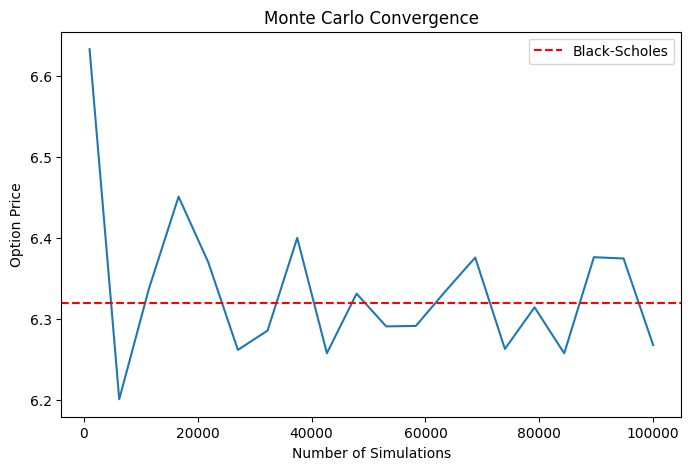

In [25]:
sim_sizes = np.linspace(1000, 100000, 20, dtype=int)
mc_estimates = []

for n in sim_sizes:
    price = monte_carlo_call(S0, K_atm, T_atm, r, sigma_atm, n_sim=n)
    mc_estimates.append(price)

plt.figure(figsize=(8,5))
plt.plot(sim_sizes, mc_estimates)
plt.axhline(bs_price, color='red', linestyle='--', label='Black-Scholes')
plt.xlabel("Number of Simulations")
plt.ylabel("Option Price")
plt.title("Monte Carlo Convergence")
plt.legend()
plt.show()


In [26]:
def simulate_paths(S, T, r, sigma, steps=100, n_sim=20):
    dt = T / steps
    paths = np.zeros((steps, n_sim))
    paths[0] = S

    for t in range(1, steps):
        Z = np.random.normal(0, 1, n_sim)
        paths[t] = paths[t-1] * np.exp(
            (r - 0.5*sigma**2)*dt + sigma*np.sqrt(dt)*Z
        )

    return paths


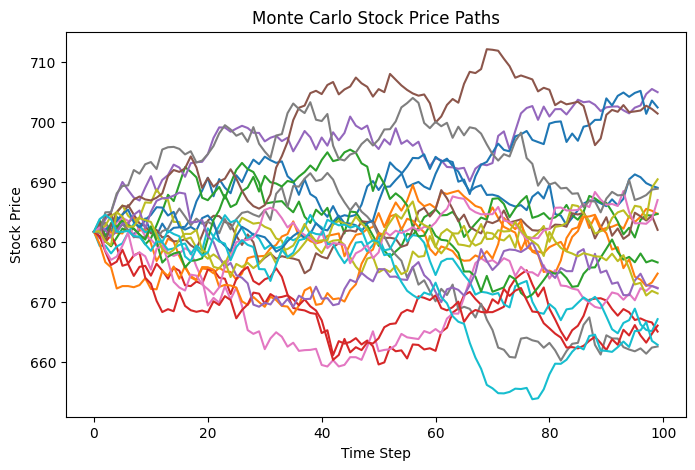

In [27]:
paths = simulate_paths(S0, T_atm, r, sigma_atm)

plt.figure(figsize=(8,5))
plt.plot(paths)
plt.title("Monte Carlo Stock Price Paths")
plt.xlabel("Time Step")
plt.ylabel("Stock Price")
plt.show()


Phase 6

In [28]:
sigma_grid = np.linspace(0.05, 0.6, 100)
loss_values = []

market_price = atm_option["lastPrice"]

for sigma in sigma_grid:
    model_price = black_scholes_call(S0, K_atm, T_atm, r, sigma)
    loss = (model_price - market_price)**2
    loss_values.append(loss)


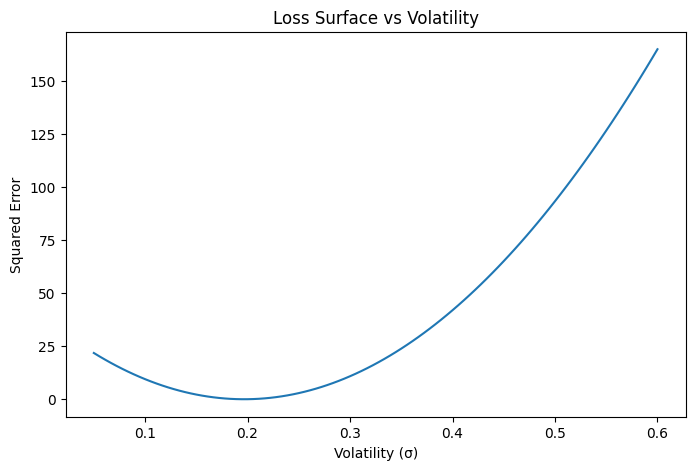

In [29]:
plt.figure(figsize=(8,5))
plt.plot(sigma_grid, loss_values)
plt.xlabel("Volatility (σ)")
plt.ylabel("Squared Error")
plt.title("Loss Surface vs Volatility")
plt.show()


In [30]:
sigma_vals = np.linspace(0.05, 0.6, 50)
r_vals = np.linspace(0.01, 0.08, 50)

Sigma, R = np.meshgrid(sigma_vals, r_vals)
Loss = np.zeros_like(Sigma)

for i in range(len(r_vals)):
    for j in range(len(sigma_vals)):
        price = black_scholes_call(S0, K_atm, T_atm, r_vals[i], sigma_vals[j])
        Loss[i,j] = (price - market_price)**2


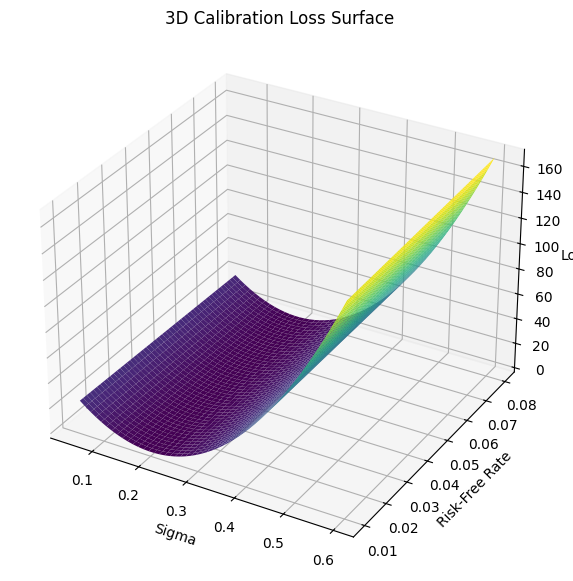

In [31]:
fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(Sigma, R, Loss, cmap='viridis')

ax.set_xlabel("Sigma")
ax.set_ylabel("Risk-Free Rate")
ax.set_zlabel("Loss")

plt.title("3D Calibration Loss Surface")
plt.show()


Phase 7

In [32]:
def calibration_loss(sigma, r):
    price = black_scholes_call(S0, K_atm, T_atm, r, sigma)
    return (price - market_price)**2


In [33]:
def numerical_gradient(sigma, r, h=1e-5):

    dL_dsigma = (
        calibration_loss(sigma + h, r)
        - calibration_loss(sigma - h, r)
    ) / (2*h)

    dL_dr = (
        calibration_loss(sigma, r + h)
        - calibration_loss(sigma, r - h)
    ) / (2*h)

    return np.array([dL_dsigma, dL_dr])


In [34]:
sigma_init = 0.3
r_init = 0.05

learning_rate = 0.01
n_steps = 50

trajectory = []

sigma, r_val = sigma_init, r_init

for _ in range(n_steps):

    trajectory.append([sigma, r_val])

    grad = numerical_gradient(sigma, r_val)

    sigma -= learning_rate * grad[0]
    r_val -= learning_rate * grad[1]

trajectory = np.array(trajectory)


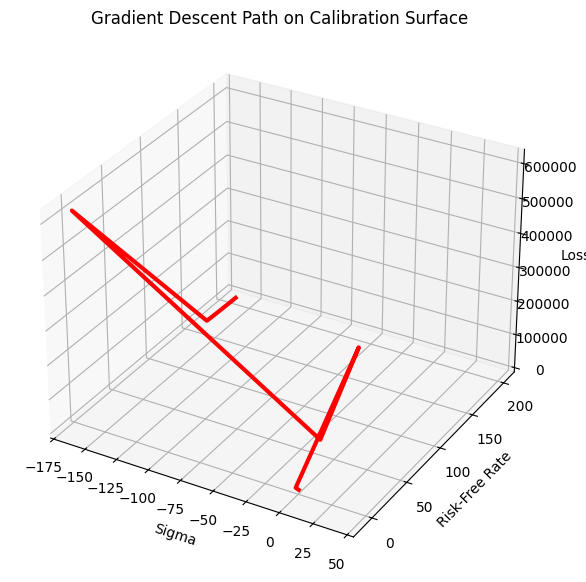

In [35]:
fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(Sigma, R, Loss, cmap='viridis', alpha=0.6)

# Compute loss along trajectory
loss_traj = [calibration_loss(s, rr) for s, rr in trajectory]

ax.plot(
    trajectory[:,0],
    trajectory[:,1],
    loss_traj,
    color='red',
    linewidth=3
)

ax.set_xlabel("Sigma")
ax.set_ylabel("Risk-Free Rate")
ax.set_zlabel("Loss")

plt.title("Gradient Descent Path on Calibration Surface")
plt.show()


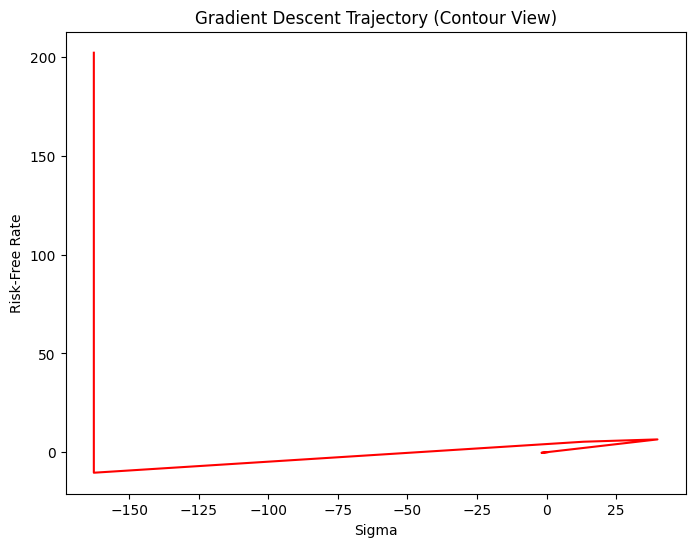

In [36]:
plt.figure(figsize=(8,6))

plt.contour(Sigma, R, Loss, levels=30)
plt.plot(trajectory[:,0], trajectory[:,1], color='red')
plt.xlabel("Sigma")
plt.ylabel("Risk-Free Rate")
plt.title("Gradient Descent Trajectory (Contour View)")
plt.show()


Plotting

In [37]:
import plotly.graph_objects as go
import numpy as np

fig = go.Figure(data=[go.Surface(
    x=Sigma,
    y=R,
    z=Loss,
    colorscale='Viridis'
)])

fig.update_layout(
    template="plotly_dark",
    scene=dict(
        xaxis_title="Sigma",
        yaxis_title="Risk-Free Rate",
        zaxis_title="Loss",
    )
)

# Camera rotation animation
frames = []

for angle in np.linspace(0, 360, 120):
    frames.append(go.Frame(
        layout=dict(
            scene_camera=dict(
                eye=dict(
                    x=2*np.cos(np.radians(angle)),
                    y=2*np.sin(np.radians(angle)),
                    z=1.5
                )
            )
        )
    ))

fig.frames = frames

fig.update_layout(
    updatemenus=[dict(
        type="buttons",
        buttons=[dict(
            label="Play",
            method="animate",
            args=[None]
        )]
    )]
)

fig.show()


In [38]:
fig = go.Figure()

# Surface
fig.add_trace(go.Surface(
    x=Sigma,
    y=R,
    z=Loss,
    colorscale='Viridis',
    opacity=0.7
))

# Create frames for descent
frames = []

for i in range(len(trajectory)):

    loss_val = calibration_loss(
        trajectory[i,0],
        trajectory[i,1]
    )

    frames.append(go.Frame(
        data=[
            go.Surface(
                x=Sigma,
                y=R,
                z=Loss,
                colorscale='Viridis',
                opacity=0.7
            ),
            go.Scatter3d(
                x=[trajectory[i,0]],
                y=[trajectory[i,1]],
                z=[loss_val],
                mode='markers',
                marker=dict(size=6, color='red')
            )
        ]
    ))

fig.frames = frames

fig.update_layout(
    template="plotly_dark",
    scene=dict(
        xaxis_title="Sigma",
        yaxis_title="Risk-Free Rate",
        zaxis_title="Loss"
    ),
    updatemenus=[dict(
        type="buttons",
        buttons=[dict(label="Play",
                      method="animate",
                      args=[None])]
    )]
)

fig.show()


In [39]:
frames = []

for i in range(len(sim_sizes)):
    frames.append(go.Frame(
        data=[go.Scatter(
            x=sim_sizes[:i+1],
            y=mc_estimates[:i+1],
            mode='lines'
        )]
    ))

fig = go.Figure(
    data=[go.Scatter(x=[], y=[], mode='lines')],
    frames=frames
)

fig.update_layout(
    template="plotly_dark",
    xaxis_title="Number of Simulations",
    yaxis_title="Option Price",
    updatemenus=[dict(
        type="buttons",
        buttons=[dict(label="Play",
                      method="animate",
                      args=[None])]
    )]
)

fig.show()


In [40]:
fig.write_html("quant_surface_animation.html")
